# Exercice 1.2 Visualisations univariées et bivariées sur Ames Housing

**Séance 2 Visualisations univariées et bivariées**

---



## Contexte

Les statistiques descriptives de la séance précédente vous ont donné une image *chiffrée* des données. Mais comme le rappelle le **Quartet d'Anscombe** : quatre jeux de données peuvent partager exactement la même moyenne, variance, et corrélation linéaire tout en ayant des structures radicalement différentes. Les statistiques compriment l'information, la visualisation la révèle.

Dans cet exercice, vous allez produire des graphiques qui racontent quelque chose, en appliquant les principes du cours (Tufte, Cleveland, accessibilité) pour que chaque élément visuel serve l'analyse.

---



## Objectifs d'apprentissage

- Sélectionner le type de visualisation adapté à la nature de la variable et à l'objectif analytique
- Créer des graphiques univariés et bivariés avec `matplotlib` et `seaborn`
- Appliquer les principes de perception visuelle (Cleveland) et de minimalisme graphique (Tufte)
- Utiliser des palettes de couleurs adaptées au type de données et accessibles
- Annoter des graphiques avec des repères contextuels utiles
- Exporter deux graphiques au format publication-ready

---



## Variables utilisées dans cet exercice

| Variable | Description | Type |
|----------|-------------|------|
| `GrLivArea` | Surface habitable (ft²) | Quantitative continue |
| `SalePrice` | Prix de vente ($) | Quantitative continue |
| `LotArea` | Surface du terrain (ft²) | Quantitative continue |
| `YearBuilt` | Année de construction | Quantitative discrète |
| `OverallQual` | Note de qualité (1 à 10) | Ordinale |
| `Neighborhood` | Quartier | Qualitative nominale |
| `HouseStyle` | Style architectural | Qualitative nominale |
| `SaleCondition` | Condition de vente | Qualitative nominale |

---



## Section 1: Imports et configuration

**Ce que vous devez faire :**
- Importez les bibliothèques nécessaires : pandas, numpy, matplotlib, seaborn.
- Chargez le dataset Ames Housing et récupérez le `df_subset` de l'exercice précédent (ou recréez-le).
- Configurez un thème seaborn global et choisissez une palette de couleur pour homogénéiser l'apparence de tous vos graphiques.




In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AmesHousing.csv")
print(df.head())

df = df.drop(columns=df.columns[df.isnull().sum() * 100.0 / df.shape[0] > 50])
df = df.drop_duplicates()

df_subset = df[["Gr Liv Area", "SalePrice", "Lot Area", "Year Built", "Overall Qual"]]
print(df_subset.info())

sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0    534  531363010           20        RL          80.0      9605   Pave   
1    803  906203120           20        RL          90.0     14684   Pave   
2    956  916176030           20        RL           NaN     14375   Pave   
3    460  528180130          120        RL          48.0      6472   Pave   
4    487  528290030           80        RL          61.0      9734   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC Fence Misc Feature  \
0   NaN       Reg          Lvl  ...         0     NaN   NaN          NaN   
1   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   
2   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   
3   NaN       Reg          Lvl  ...         0     NaN   NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0        0    

---
## Section 2: Visualisations univariées : variables continues

**Objectif** : explorer la distribution de `GrLivArea`, `SalePrice` et `LotArea` avec plusieurs types de graphiques, et comprendre ce que chacun apporte.



### 2.1 Histogramme + KDE côte à côte

**Ce que vous devez faire :**
- Pour chaque variable continue, créez une figure avec deux sous-graphiques côte à côte :
   - À gauche : un **histogramme** avec courbe KDE superposée
   - À droite : une **boîte à moustaches (boxplot)**
- Sur l'histogramme, ajoutez :
   - Une ligne verticale pour la **moyenne** (couleur et style à votre choix)
   - Une ligne verticale pour la **médiane** (couleur et style différents)
   - Une légende qui identifie les deux lignes

> `sns.histplot()` accepte un paramètre `kde`. Pour les lignes verticales, `ax.axvline()` est la fonction à utiliser.  Pensez à passer l'objet `ax` à seaborn pour définir la sous-figure.



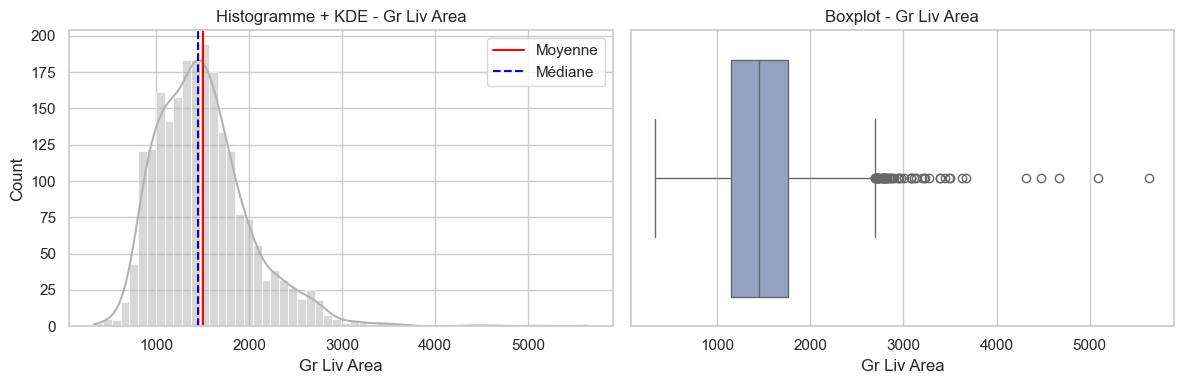

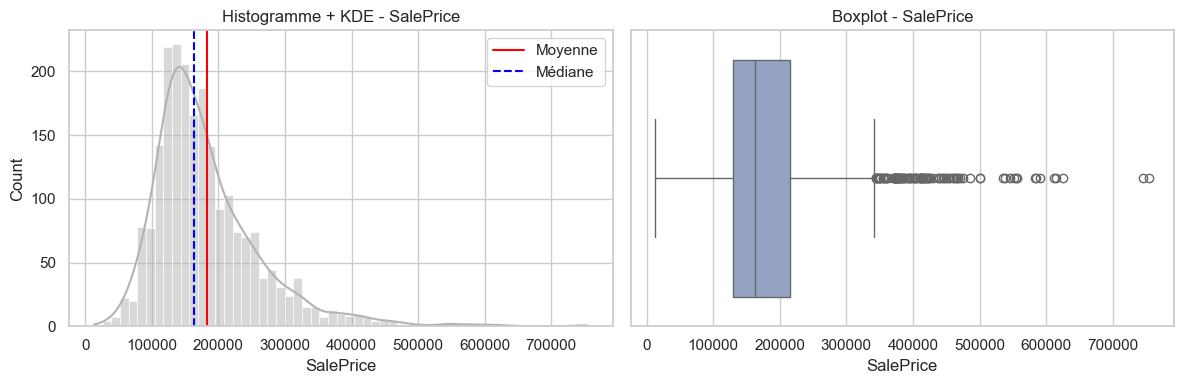

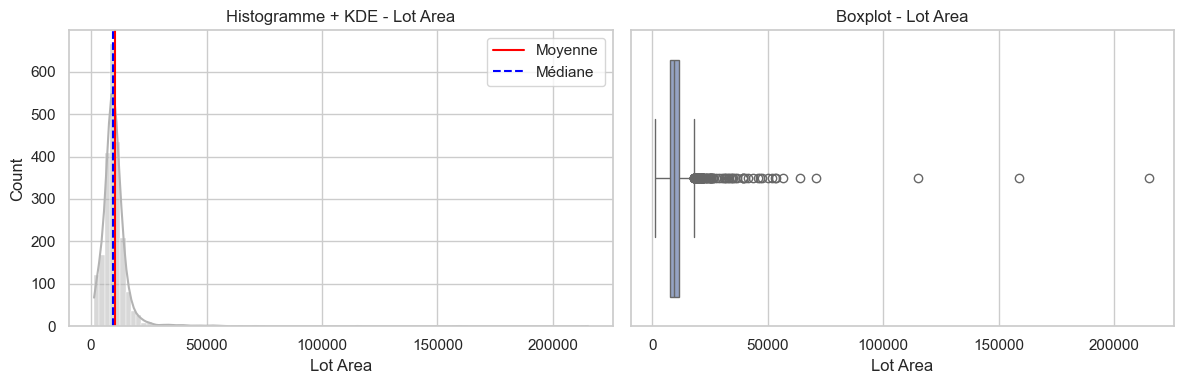

In [19]:
continuous_vars = ["Gr Liv Area", "SalePrice", "Lot Area"]
for col in continuous_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_subset[col], kde=True, ax=axes[0], color=palette[7])
    axes[0].axvline(df_subset[col].mean(), color="red", linestyle="-", label="Moyenne")
    axes[0].axvline(df_subset[col].median(), color="blue", linestyle="--", label="Médiane")
    axes[0].set_title(f"Histogramme + KDE - {col}")
    axes[0].legend()

    # axvline cad “axis vertical line”

    #  axes[0]  cad premier graphique
    #  axes[1]  cad deuxième
    #  axes[2]  cad troisième

    sns.boxplot(x=df_subset[col], ax=axes[1], color=palette[2])
    axes[1].set_title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.show()

**Dans une cellule Markdown, répondez pour chaque variable :**
- Quelle est la forme de la distribution (symétrique, étalée à droite/gauche, bimodale) ?
- L'écart entre la moyenne et la médiane est-il cohérent avec la forme observée ?
- Que vous apporte le boxplot que l'histogramme ne montrait pas directement ?

### 2.2 Violin plot

**Ce que vous devez faire :**
- Créez un **violin plot** pour les trois variables.

> Les trois variables n'ont pas la même échelle: les comparer sur un même axe serait trompeur. Utilisez des sous-graphiques séparés. `sns.violinplot()` peut afficher la différentes visualisations avec le paramètre `inner`.



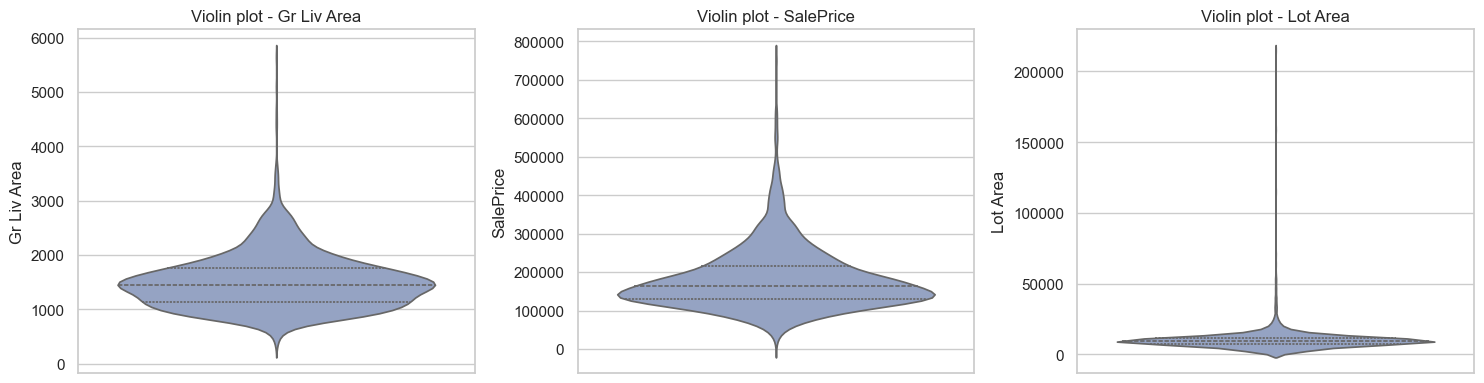

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, continuous_vars):
    sns.violinplot(y=df_subset[col], ax=ax, inner="quartile", color=palette[2])
    ax.set_title(f"Violin plot - {col}")
plt.tight_layout()
plt.show()

**Dans une cellule Markdown, répondez :**
- Qu'apporte le violin plot par rapport au boxplot seul ? Dans quelle situation le préférieriez-vous ?
- Pour `LotArea`, la forme du violon vous semble-t-elle cohérente avec le skewness calculé à l'exercice précédent ?



---
## Section 3: Visualisations univariées : variables discrètes et qualitatives



### 3.1 Variables discrètes : `OverallQual` et `YearBuilt`

**Ce que vous devez faire :**
- Pour `OverallQual`, créez un **diagramme en barres des effectifs**. Chaque barre doit représenter exactement une valeur (1 à 10), pas un intervalle.
- Pour `YearBuilt`, créez un diagramme en barres des effectifs. Comme il y a beaucoup d'années, rendez les étiquettes de l'axe x lisibles.

> `value_counts().sort_index()` vous donne les effectifs dans l'ordre. La méthode `.plot(kind='bar')` ou `sns.barplot()` permet de les tracer. 

> Pour `YearBuilt`, utilisez `ax.set_xticks()` et `ax.set_xticklabels()` avec une sélection d'années (toutes les 10 ans par exemple).



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qual_counts = df_subset["Overall Qual"].value_counts().sort_index()
axes[0].bar(qual_counts.index.astype(str), qual_counts.values, color=palette[3])
axes[0].set_title("Overall Qual - effectifs")
axes[0].set_xlabel("Overall Qual")
axes[0].set_ylabel("Effectifs")

year_counts = df_subset["Year Built"].value_counts().sort_index()
x_year = np.arange(len(year_counts))
axes[1].bar(x_year, year_counts.values, color=palette[4])
tick_step = max(1, len(x_year) // 15)
axes[1].set_xticks(x_year[::tick_step])
axes[1].set_xticklabels(year_counts.index.astype(int)[::tick_step], rotation=90)
axes[1].set_title("Year Built - effectifs")
axes[1].set_xlabel("Year Built")
axes[1].set_ylabel("Effectifs")

plt.tight_layout()
plt.show()

**Dans une cellule Markdown, répondez :**
- Pourquoi un histogramme serait-il moins adapté qu'un diagramme en barres pour ces deux variables ?
- La distribution de `OverallQual` vous semble-t-elle symétrique ? Que dit le skewness calculé précédemment ?
- Identifiez sur le graphique de `YearBuilt` une période de construction particulièrement active. À quoi peut-elle correspondre ?



### 3.2 Variables qualitatives : `Neighborhood`, `HouseStyle`, `SaleCondition`

**Ce que vous devez faire :**
- Pour chaque variable qualitative :
   - Calculez les **fréquences relatives** (proportions en %)
   - Tracez un **diagramme en barres horizontal**, trié par fréquence décroissante
   - Affichez la valeur de chaque barre directement sur le graphique

- Pour `Neighborhood` (beaucoup de catégories), ne représentez que les **10 quartiers les plus fréquents**. Mentionnez en Markdown le nombre de quartiers exclus et leur proportion cumulée.

> `value_counts(normalize=True)` renvoie des proportions entre 0 et 1: multipliez par 100 pour des pourcentages. 

> Pour afficher les valeurs sur les barres, `ax.bar_label(ax.containers[0], fmt='%.1f%%')` fonctionne sur un barplot matplotlib. 

> Pour seaborn, vous pouvez itérer sur les patches avec `ax.patches`. Pour le tri horizontal, `barh()` ou `kind='barh'` dans pandas.

> Pour la palette de couleurs : les variables qualitatives nominales appellent une palette **qualitative** (couleurs équivalentes en luminosité). 

> Évitez les dégradés séquentiels qui suggèrent un ordre inexistant.



Neighborhood: top 10 affichés, 18 catégories exclues, proportion exclue=28.49%


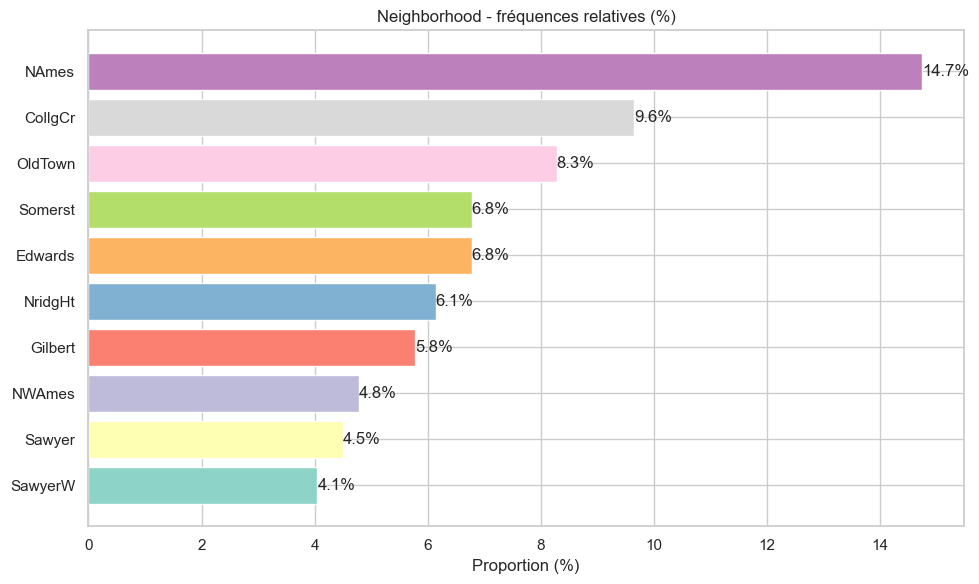

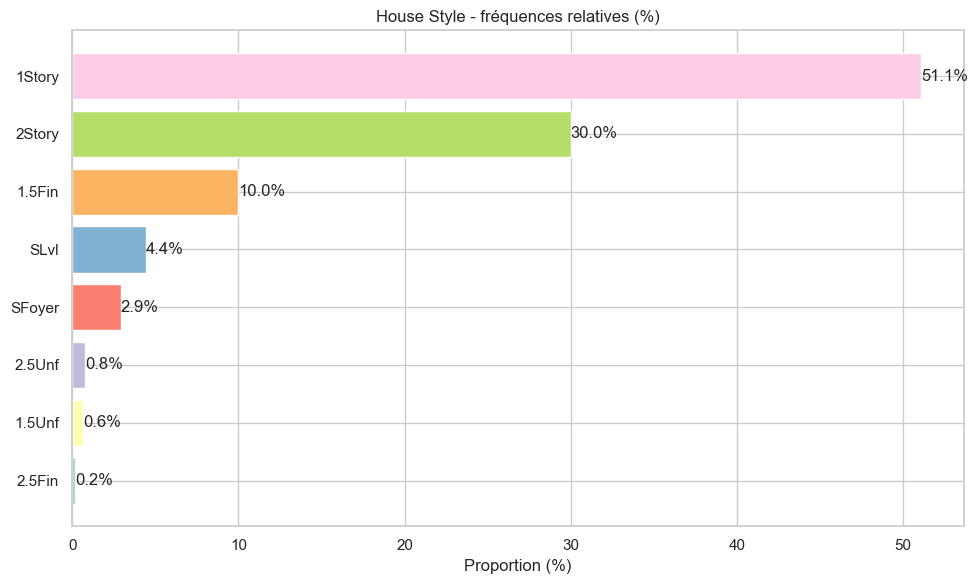

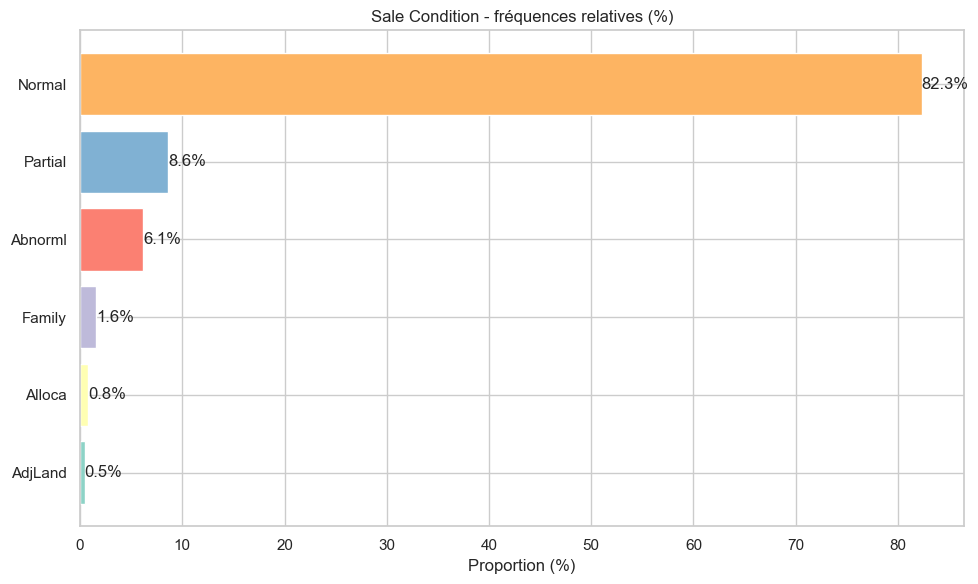

In [5]:
def plot_relative_freq(df_in: pd.DataFrame, col: str, top_n: int | None = None) -> None:
    freq = df_in[col].value_counts(normalize=True) * 100
    if top_n is not None:
        top = freq.head(top_n).sort_values(ascending=True)
        excluded_n = len(freq) - top_n
        excluded_pct = float(freq.iloc[top_n:].sum())
        print(
            f"{col}: top {top_n} affichés, {excluded_n} catégories exclues, "
            f"proportion exclue={excluded_pct:.2f}%"
        )
        data = top
    else:
        data = freq.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(data.index, data.values, color=sns.color_palette("Set3", len(data)))
    ax.set_title(f"{col} - fréquences relatives (%)")
    ax.set_xlabel("Proportion (%)")
    ax.bar_label(bars, fmt="%.1f%%")
    plt.tight_layout()
    plt.show()


plot_relative_freq(df, "Neighborhood", top_n=10)
plot_relative_freq(df, "House Style")
plot_relative_freq(df, "Sale Condition")

**Dans une cellule Markdown, répondez :**
- Quel quartier est le plus représenté ? Y a-t-il un déséquilibre important ?
- La condition de vente "Normal" est-elle dominante ? Qu'implique ce déséquilibre pour un modèle prédictif ?
- Pour `HouseStyle`, y a-t-il des styles si rares qu'ils pourraient poser problème lors d'un encodage ?



### 4.1 Deux variables quantitatives : `GrLivArea` vs `SalePrice`

**Ce que vous devez faire :**
- Tracez un **scatterplot** de `GrLivArea` (axe X) vs `SalePrice` (axe Y).
- Superposez une **droite de régression** avec son intervalle de confiance.
- Colorez les points selon `OverallQual` pour ajouter une troisième dimension.


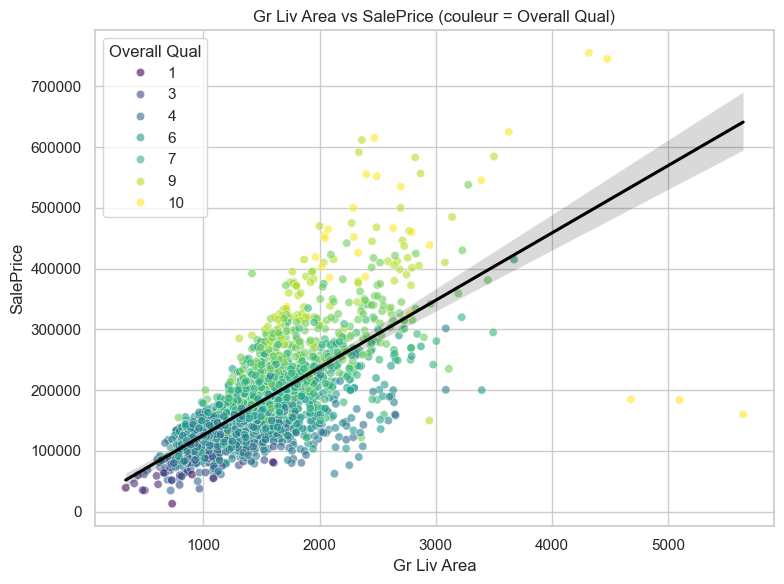

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y="SalePrice",
    hue="Overall Qual",
    palette="viridis",
    alpha=0.6,
)
sns.regplot(data=df, x="Gr Liv Area", y="SalePrice", scatter=False, color="black", ci=95)
plt.title("Gr Liv Area vs SalePrice (couleur = Overall Qual)")
plt.tight_layout()
plt.show()

**Dans une cellule Markdown, répondez :**
- La relation entre surface et prix semble-t-elle linéaire ? Y a-t-il des points qui s'écartent clairement de la tendance ?
- Identifiez visuellement 2 ou 3 observations potentiellement influentes (celles qui tirent la droite de régression). Que remarquez-vous sur leur qualité ?
- Que vous apporte la couleur par `OverallQual` ? Est-ce cohérent avec votre hypothèse de l'exercice précédent ?



### 4.2 Quantitatif × Ordinal : `OverallQual` vs `SalePrice`

**Ce que vous devez faire :**
- Tracez des **boxplots de `SalePrice` par niveau de `OverallQual`** (un boxplot par note de 1 à 10). 
- Superposez un **strip plot** (points individuels) pour visualiser la dispersion réelle.
- Ajoutez une ligne horizontale indiquant le prix médian global.

> Pour avoir plusieurs boxplots dans le même graphique, précisez data, x et y au lieu de donner le jeu de donnée entier.

> Pour le strip plot, `sns.stripplot()` avec `alpha=0.3` et `jitter=True` se superpose bien. 
> L'ordre des appels compte : le boxplot en premier, puis le strip plot par-dessus. 

> La ligne médiane : `ax.axhline()`.



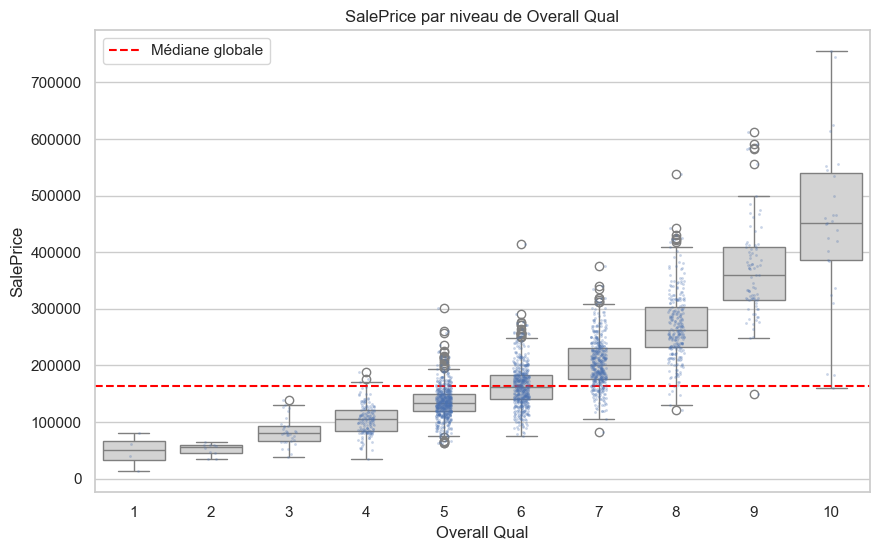

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="Overall Qual", y="SalePrice", color="lightgray", ax=ax)
sns.stripplot(data=df, x="Overall Qual", y="SalePrice", alpha=0.3, jitter=True, size=2, ax=ax)
#ax=ax : dessine ce graphique sur CET axe précis
#size=2 :la taille des points
ax.axhline(df["SalePrice"].median(), color="red", linestyle="--", label="Médiane globale")
ax.set_title("SalePrice par niveau de Overall Qual")
ax.legend()
plt.show()

**Dans une cellule Markdown, répondez :**
- La relation qualité-prix est-elle linéaire ? Y a-t-il un seuil à partir duquel le prix augmente plus fortement ?
- Certains niveaux de qualité ont-ils une dispersion de prix très élevée ? Qu'est-ce que cela indique ?
- Cette visualisation confirme-t-elle ou infirme-t-elle l'une de vos hypothèses de l'exercice précédent ?



1-La relation entre OverallQual et SalePrice est croissante, mais pas linéaire.  
Le prix augmente à partir des les niveaux de qualité 3-6.  
Le prix augmente plus à partir des les niveaux 7-8.   

2-Les biens exceptioonnel ont une grande qualité.  
La dispersion des prix augmente avec la qualité :  
Faibles qualités : dispersion faible - prix concentré
Qualités élevées : dispersion élévé
Les maisons de forte qualité peuvent varier fortement en prix.  

3-Cette visualisation confirme l’hypothèse de l'exercice précedent :
La qualité globale (OverallQual) est fortement corrélée au prix.


### 4.3 Matrice de corrélation

**Ce que vous devez faire :**
- Sélectionnez au moins 6 variables numériques pertinentes (incluant `SalePrice`) et calculez la matrice de corrélation de Pearson.
- Visualisez-la sous forme de **heatmap** annotée avec les coefficients.


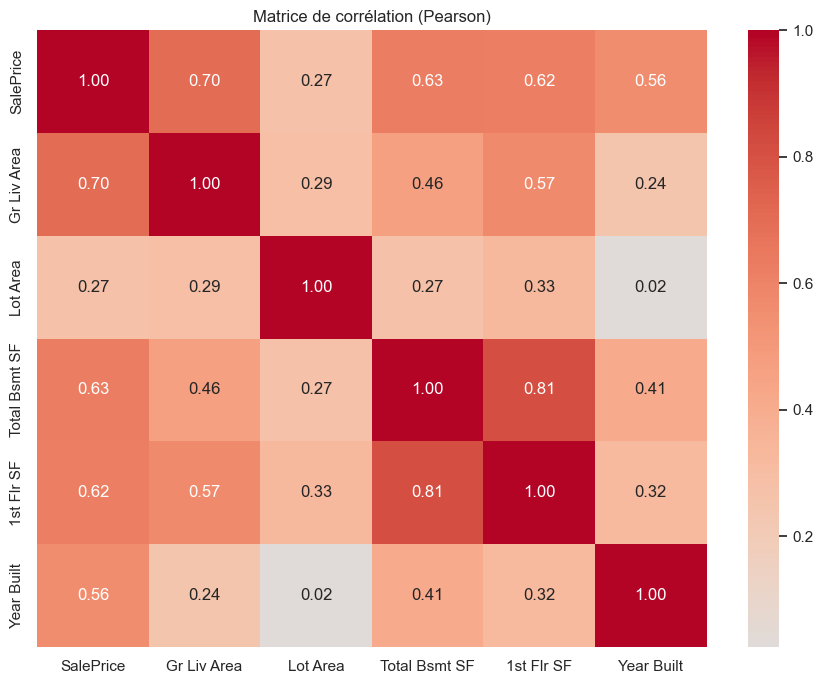

In [39]:
corr_vars = ["SalePrice", "Gr Liv Area", "Lot Area", "Total Bsmt SF", "1st Flr SF", "Year Built"]
corr = df[corr_vars].corr(method="pearson")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.show()

**Dans une cellule Markdown, répondez :**
- Quelle variable est la plus fortement corrélée à `SalePrice` ?
- Y a-t-il des paires de variables prédictives fortement corrélées entre elles (multicolinéarité potentielle) ?
- Une corrélation vous semble-t-elle surprenante ou contre-intuitive ? Formulez une hypothèse explicative.



1-C'est 1 st Flr SF à 0,81 puis Gr Liv Area à 0,7.  
La surface du rdc cause une forte variaton sur le prix puis la surface habitable totale.   
2-paires de variables prédictives.   
1stFlrSF avec  TotRmsAbvGrd.  
GrLivArea avec TotRmsAbvGrd.  
GarageCars avec GarageArea.  
Le rdc peut avoir un impact sur le prrix plus fort que la  et dépend donc des acheteurs et de leur préférence.

---
## Section 5: Exercice "Bad Viz"

**Objectif** : identifier les défauts courants en visualisation et les corriger.

Voici trois graphiques volontairement mal construits à recréer depuis le dataset Ames Housing, puis à corriger.

---



### Graphique A


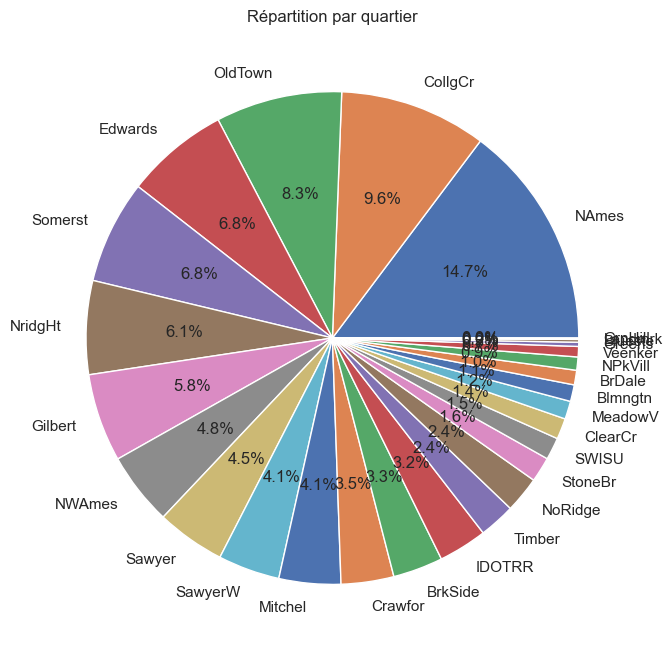


Bad Viz 1 - Défauts: pie chart surcharge visuelle + comparaison des angles difficile.
Principe violé: charge cognitive, perceptual ranking (Cleveland).
Correction: bar chart horizontal trié.


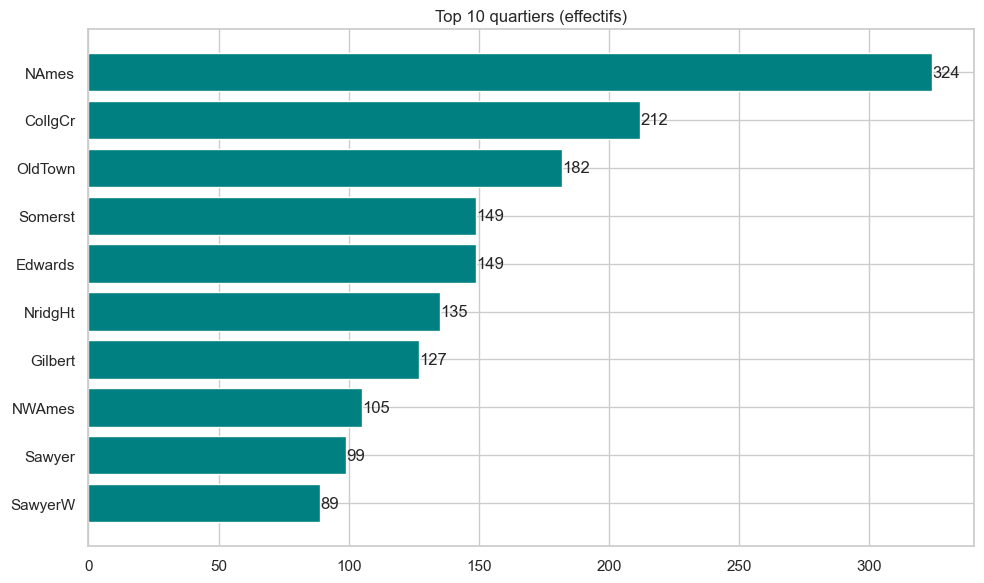

In [ ]:
# Graphique à corriger: exécutez ce code et analysez ses défauts
neighborhood_counts = df['Neighborhood'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(neighborhood_counts, labels=neighborhood_counts.index, autopct='%1.1f%%')
plt.title('Répartition par quartier')
plt.show()

print("\nBad Viz 1 - Défauts: pie chart surcharge visuelle + comparaison des angles difficile.")
print("Principe violé: charge cognitive, perceptual ranking (Cleveland).")
print("Correction: bar chart horizontal trié.")

fig, ax = plt.subplots(figsize=(10, 6))
top_neighborhood = df["Neighborhood"].value_counts().head(10).sort_values()
bars = ax.barh(top_neighborhood.index, top_neighborhood.values, color="teal")
ax.set_title("Top 10 quartiers (effectifs)")
ax.bar_label(bars)
plt.tight_layout()
plt.show()

**Ce que vous devez faire :**
- Listez au moins **deux défauts** de ce graphique en citant les principes du cours (Cleveland, Tufte).
- Produisez une **version corrigée** qui transmet la même information de façon plus claire.

---



### Graphique B


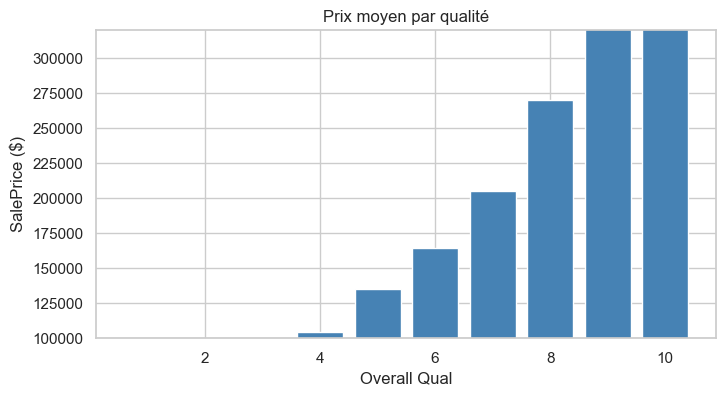


Bad Viz 2 - Défauts: axe Y tronqué exagère visuellement les différences.
Correction: axe à zéro + médiane plus robuste aux outliers.


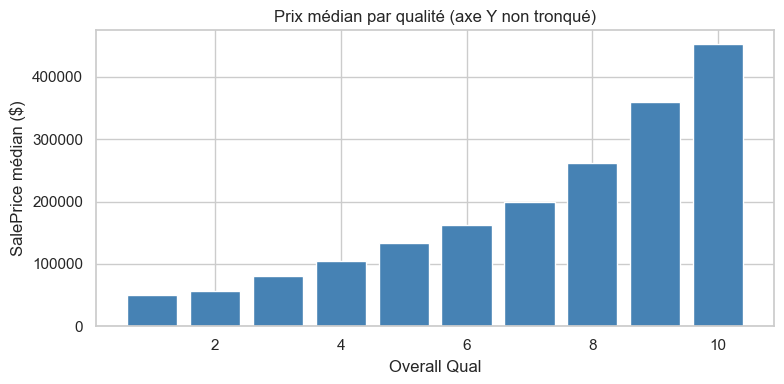

In [40]:
# Graphique à corriger: exécutez ce code et analysez ses défauts
fig, ax = plt.subplots(figsize=(8, 4))
qual_means = df.groupby('Overall Qual')['SalePrice'].mean()
ax.bar(qual_means.index, qual_means.values, color='steelblue')
ax.set_ylim(100000, 320000)
ax.set_title('Prix moyen par qualité')
ax.set_xlabel('Overall Qual')
ax.set_ylabel('SalePrice ($)')
plt.show()

print("\nBad Viz 2 - Défauts: axe Y tronqué exagère visuellement les différences.")
print("Correction: axe à zéro + médiane plus robuste aux outliers.")

fig, ax = plt.subplots(figsize=(8, 4))
qual_medians = df.groupby("Overall Qual")["SalePrice"].median()
ax.bar(qual_medians.index, qual_medians.values, color="steelblue")
ax.set_ylim(bottom=0)
ax.set_title("Prix médian par qualité (axe Y non tronqué)")
ax.set_xlabel("Overall Qual")
ax.set_ylabel("SalePrice médian ($)")
plt.tight_layout()
plt.show()

**Ce que vous devez faire :**
- Expliquez pourquoi l'axe Y tronqué est problématique ici. Quel effet visuel crée-t-il ?
- Produisez une **version corrigée**: et réfléchissez si la moyenne est le bon indicateur ici, ou si la médiane serait plus appropriée (justifiez).

---



### Graphique C

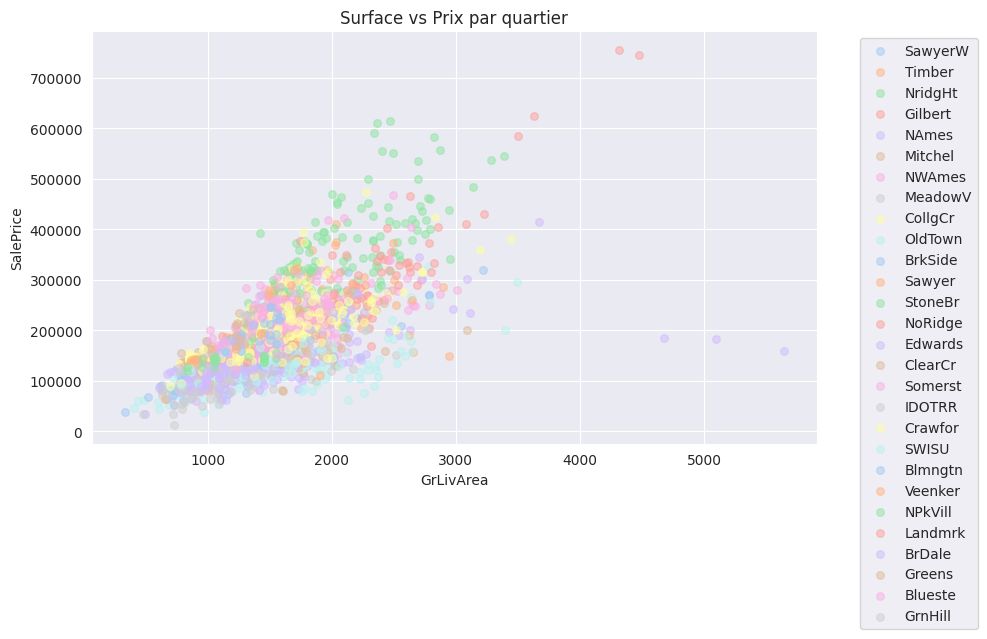

In [ ]:
# Graphique à corriger: exécutez ce code et analysez ses défauts
fig, ax = plt.subplots(figsize=(10, 6))
for neighborhood in df['Neighborhood'].unique():
    subset = df[df['Neighborhood'] == neighborhood]
    ax.scatter(subset['Gr Liv Area'], subset['SalePrice'],
               label=neighborhood, alpha=0.5, s=30)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Surface vs Prix par quartier')
ax.set_xlabel('Gr Liv Area')
ax.set_ylabel('SalePrice')
plt.tight_layout()
plt.show()

print("\nBad Viz 3 - Défauts: trop de catégories/couleurs, légende illisible, surcharge cognitive.")
print("Correction: ne garder que les 5 quartiers les plus fréquents.")

top5 = df["Neighborhood"].value_counts().head(5).index
df_top5 = df[df["Neighborhood"].isin(top5)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_top5,
    x="Gr Liv Area",
    y="SalePrice",
    hue="Neighborhood",
    alpha=0.6,
    s=35,
    ax=ax,
)
ax.set_title("Surface vs Prix - Top 5 quartiers")
plt.tight_layout()
plt.show()

**Ce que vous devez faire :**
- Identifiez les problèmes de ce graphique du point de vue de la **charge cognitive** et de l'utilisation de la couleur.
- Proposez et produisez une **version simplifiée**: une stratégie possible est de ne garder que les 5 quartiers les plus fréquents, ou de remplacer la couleur par quartier par une autre encodage. Justifiez votre choix.

> Pour chaque mauvaise visualisation, votre correction doit être accompagnée d'une cellule Markdown structurée ainsi : **Défauts identifiés** / **Principe violé** (Tufte, Cleveland, ou charge cognitive) / **Correction apportée**.

---



## Checklist avant de rendre

- [ ] Le notebook s'exécute du début à la fin sans erreur (`Restart & Run All`)
- [ ] Chaque graphique a un titre, des labels d'axes avec unités, et une légende si plusieurs séries
- [ ] Chaque section de visualisation est suivie d'une interprétation en Markdown avec des réponses aux questions posées
- [ ] Les trois "Bad Viz" sont corrigées avec justification structurée
- [ ] Deux fichiers PDF sont exportés dans le même dossier que le notebook
- [ ] Les palettes de couleurs sont cohérentes avec le type de données (qualitative / séquentielle / divergente)

---

